# Movie Genre Classification

**CODSOFT Machine Learning Internship — Task 1**

## Objective
To build a machine learning model that predicts a movie's genre from its plot summary.

## Dataset
[Genre Classification Dataset IMDb](https://www.kaggle.com/datasets/hijest/genre-classification-dataset-imdb)
- `train_data.txt` — records in the format `ID ::: TITLE ::: GENRE ::: DESCRIPTION`
- Each record corresponds to one movie, with its plot summary and genre label

## Methodology
1. Data loading and exploratory data analysis
2. Text preprocessing (lowercasing, punctuation removal)
3. Feature extraction using TF-IDF (unigrams and bigrams)
4. Model training — Multinomial Naive Bayes, Logistic Regression, and Linear SVM
5. Model evaluation using Accuracy, Macro-F1, and Weighted-F1
6. Comparison of results and final model selection


## 1. Import Libraries

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

## 2. Data Loading

In [2]:
data_rows = []

with open("../data/train_data.txt", "r", encoding="utf-8") as file:
    for line in file:
        parts = line.strip().split(" ::: ")
        if len(parts) == 4:
            data_rows.append(parts)

df = pd.DataFrame(data_rows, columns=["ID", "Title", "Genre", "Description"])

print("Total records loaded:", len(df))
df.head()

Total records loaded: 54214


,ID,Title,Genre,Description
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


In [3]:
df.info()
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 54214 entries, 0 to 54213
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ID           54214 non-null  str  
 1   Title        54214 non-null  str  
 2   Genre        54214 non-null  str  
 3   Description  54214 non-null  str  
dtypes: str(4)
memory usage: 34.6 MB

Missing values:
ID             0
Title          0
Genre          0
Description    0
dtype: int64

Duplicate rows: 0


## 3. Exploratory Data Analysis

### 3.1 Genre Distribution

In [4]:
genre_counts = df["Genre"].value_counts()
print("Number of unique genres:", genre_counts.shape[0])
print(genre_counts)

Number of unique genres: 27
Genre
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
adventure        775
music            731
romance          672
sci-fi           647
adult            590
crime            505
animation        498
sport            432
talk-show        391
fantasy          323
mystery          319
musical          277
biography        265
history          243
game-show        194
news             181
war              132
Name: count, dtype: int64


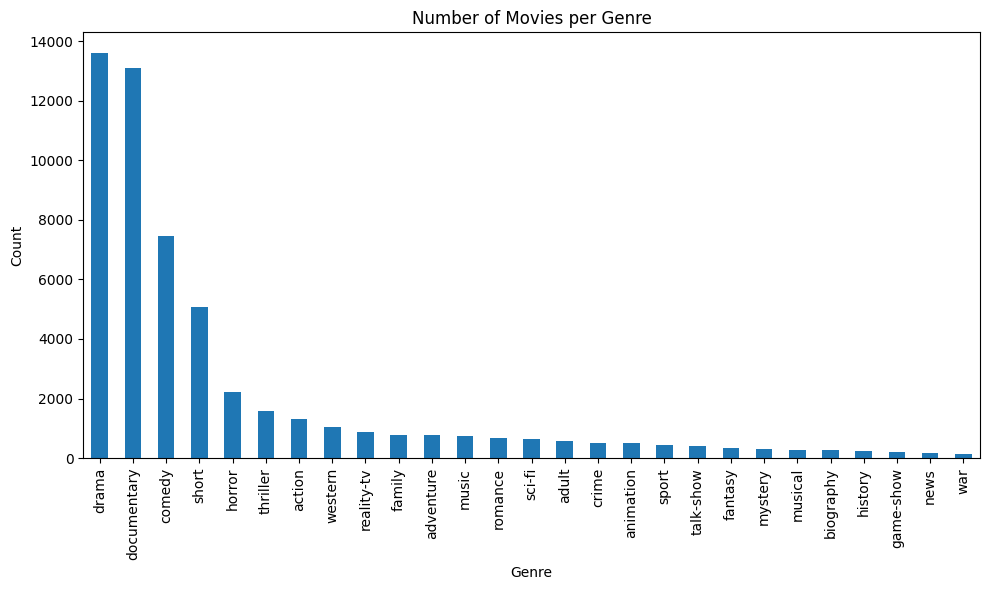

In [5]:
plt.figure(figsize=(10, 6))
genre_counts.plot(kind="bar")
plt.title("Number of Movies per Genre")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Observation:** The genre distribution is highly imbalanced. A small number of
genres (Drama, Documentary) account for a large proportion of records, while many
other genres are represented by relatively few samples. This imbalance is
addressed later through `class_weight="balanced"` and by reporting Macro-F1
alongside Accuracy.

### 3.2 Description Length

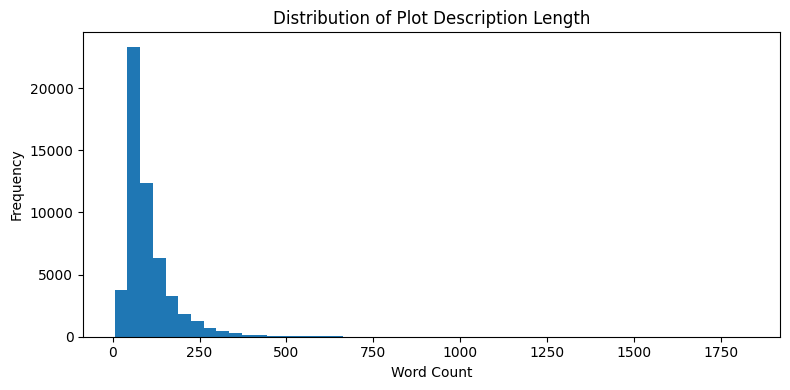

count    54214.000000
mean       101.907386
std         76.579192
min          6.000000
25%         55.000000
50%         79.000000
75%        121.000000
max       1829.000000
Name: Description_Length, dtype: float64


In [6]:
df["Description_Length"] = df["Description"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 4))
plt.hist(df["Description_Length"], bins=50)
plt.title("Distribution of Plot Description Length")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(df["Description_Length"].describe())

**Observation:** Plot descriptions vary in length but are concentrated within a
moderate word-count range. No extreme skew was found that would require truncation
or padding for this approach.

## 4. Text Preprocessing

In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["Clean_Description"] = df["Description"].apply(clean_text)
df[["Description", "Clean_Description"]].head(3)

,Description,Clean_Description
0,Listening in to a conversation between his doc...,listening in to a conversation between his doc...
1,A brother and sister with a past incestuous re...,a brother and sister with a past incestuous re...
2,As the bus empties the students for their fiel...,as the bus empties the students for their fiel...


Preprocessing steps applied: conversion to lowercase, removal of non-alphabetic
characters, and normalization of whitespace. This produces cleaner input for the
TF-IDF vectorizer by removing noise that does not contribute to genre prediction.

## 5. Train-Test Split

In [8]:
X = df["Clean_Description"]
y = df["Genre"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 43371
Testing samples: 10843


The dataset was split 80/20 into training and testing sets. Stratified sampling
was used to preserve the genre distribution across both splits, given the
imbalance identified in Section 3.1.

## 6. Feature Extraction — TF-IDF

In [9]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words="english"
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print("Training feature matrix shape:", X_train_vec.shape)
print("Vocabulary size:", len(tfidf.vocabulary_))

Training feature matrix shape: (43371, 20000)
Vocabulary size: 20000


Text data was converted into numerical feature vectors using **TF-IDF (Term
Frequency–Inverse Document Frequency)**, which assigns higher weight to terms that
are frequent within a specific description but rare across the overall corpus.
Both unigrams and bigrams were included (`ngram_range=(1,2)`) to capture
multi-word phrases in addition to individual terms. Vocabulary size was capped at
20,000 features, and terms appearing in fewer than 2 documents were excluded to
reduce noise.

## 7. Model Training

Three classifiers were trained and compared, each suited to sparse,
high-dimensional TF-IDF representations:

| Model | Characteristics |
|---|---|
| Multinomial Naive Bayes | Probabilistic baseline; fast and effective on sparse text data |
| Logistic Regression | Linear model with interpretable coefficients per feature |
| Linear SVM | Margin-based linear classifier; typically strong on high-dimensional text data |

`class_weight="balanced"` was applied to Logistic Regression and Linear SVM to
mitigate the effect of genre imbalance during training.

In [10]:
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)
print("Naive Bayes: training complete")

Naive Bayes: training complete


In [11]:
lr_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr_model.fit(X_train_vec, y_train)
print("Logistic Regression: training complete")

Logistic Regression: training complete


In [12]:
svm_model = LinearSVC(class_weight="balanced", random_state=42)
svm_model.fit(X_train_vec, y_train)
print("Linear SVM: training complete")

Linear SVM: training complete


## 8. Model Evaluation

In [13]:
nb_predictions = nb_model.predict(X_test_vec)
lr_predictions = lr_model.predict(X_test_vec)
svm_predictions = svm_model.predict(X_test_vec)

In [14]:
print("Naive Bayes")
print("Accuracy:   ", accuracy_score(y_test, nb_predictions))
print("Macro-F1:   ", f1_score(y_test, nb_predictions, average="macro"))
print("Weighted-F1:", f1_score(y_test, nb_predictions, average="weighted"))

Naive Bayes
Accuracy:    0.5000461126994374
Macro-F1:    0.09971455319193415
Weighted-F1: 0.40186785114232493


In [15]:
print("Logistic Regression")
print("Accuracy:   ", accuracy_score(y_test, lr_predictions))
print("Macro-F1:   ", f1_score(y_test, lr_predictions, average="macro"))
print("Weighted-F1:", f1_score(y_test, lr_predictions, average="weighted"))

Logistic Regression
Accuracy:    0.4887946140367057
Macro-F1:    0.3654030173202809
Weighted-F1: 0.5125546397760089


In [16]:
print("Linear SVM")
print("Accuracy:   ", accuracy_score(y_test, svm_predictions))
print("Macro-F1:   ", f1_score(y_test, svm_predictions, average="macro"))
print("Weighted-F1:", f1_score(y_test, svm_predictions, average="weighted"))

Linear SVM
Accuracy:    0.529834916536014
Macro-F1:    0.34816071273118704
Weighted-F1: 0.5369403065011225


**Metric selection rationale:** Accuracy alone is insufficient given the class
imbalance observed in Section 3.1, since a model could achieve a high accuracy
score by favoring frequent genres. Macro-F1 was included to evaluate performance
uniformly across all genres regardless of frequency, and Weighted-F1 provides a
frequency-adjusted measure between the two extremes.

## 9. Detailed Results — Best Performing Model

In [17]:
# Set to whichever model achieved the highest scores in Section 8
best_predictions = svm_predictions

print(classification_report(y_test, best_predictions))

              precision    recall  f1-score   support

      action       0.32      0.47      0.38       263
       adult       0.39      0.61      0.48       118
   adventure       0.21      0.26      0.23       155
   animation       0.16      0.22      0.18       100
   biography       0.03      0.02      0.02        53
      comedy       0.57      0.53      0.55      1490
       crime       0.13      0.18      0.15       101
 documentary       0.75      0.74      0.75      2619
       drama       0.66      0.49      0.56      2723
      family       0.20      0.26      0.23       157
     fantasy       0.09      0.11      0.10        65
   game-show       0.62      0.59      0.61        39
     history       0.11      0.12      0.11        49
      horror       0.54      0.69      0.61       441
       music       0.47      0.68      0.55       146
     musical       0.11      0.13      0.12        55
     mystery       0.05      0.06      0.06        64
        news       0.14    

### 9.1 Confusion Matrix (Top 10 Genres)

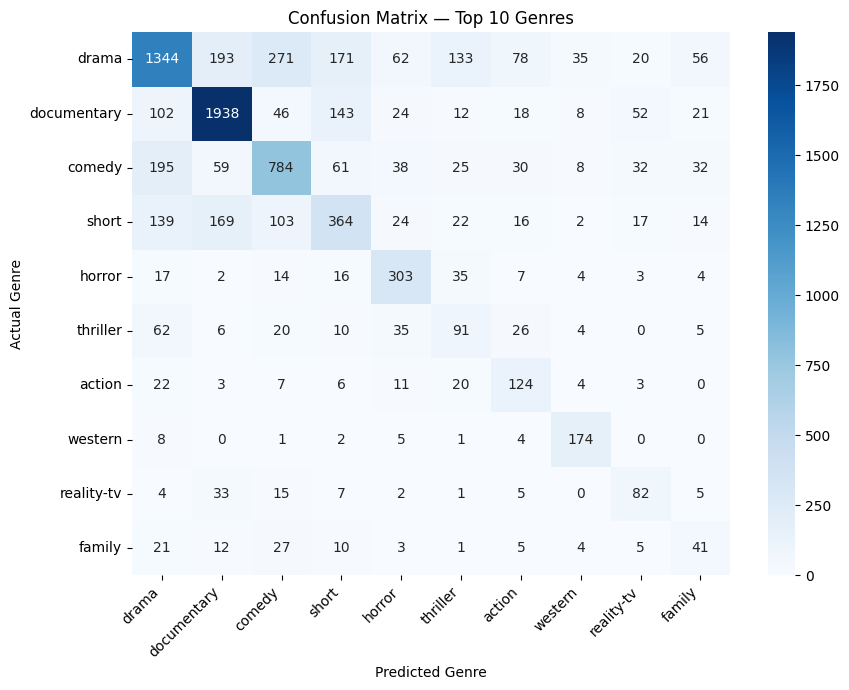

In [18]:
top_genres = genre_counts.head(10).index.tolist()
mask = y_test.isin(top_genres)

cm = confusion_matrix(
    y_test[mask],
    pd.Series(best_predictions, index=y_test.index)[mask],
    labels=top_genres
)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=top_genres, yticklabels=top_genres)
plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("Confusion Matrix — Top 10 Genres")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Observation:** Misclassifications are concentrated between genres with
overlapping thematic vocabulary — for example, Thriller and Crime, or Romance and
Drama. This reflects a limitation inherent to plot-summary text rather than a
deficiency in the modeling approach, as these genres frequently share similar
narrative language.

## 10. Inference on New Input

In [19]:
def predict_genre(plot_text):
    cleaned = clean_text(plot_text)
    vector = tfidf.transform([cleaned])
    prediction = svm_model.predict(vector)
    return prediction[0]

sample_plot = (
    "A young detective must track down a serial killer terrorizing the city "
    "before he becomes the next victim, uncovering a conspiracy that reaches "
    "the highest levels of the police department."
)
print("Predicted genre:", predict_genre(sample_plot))

Predicted genre: thriller


## 11. Conclusion

Three classifiers — Multinomial Naive Bayes, Logistic Regression, and Linear SVM —
were trained and evaluated on TF-IDF features extracted from movie plot
summaries. Model performance was assessed using Accuracy, Macro-F1, and
Weighted-F1 to account for the class imbalance present in the genre distribution.

**Key findings:**
- Genre distribution is highly imbalanced, with Drama and Documentary dominating the dataset.
- The gap between Accuracy/Weighted-F1 and Macro-F1 quantifies the impact of this imbalance on rare-genre performance.
- Misclassifications are concentrated among genres with overlapping narrative vocabulary.

**Potential improvements:**
- Incorporating movie titles alongside descriptions as additional input text
- Using pretrained word embeddings or transformer-based models for richer semantic representation
- Addressing class imbalance further through oversampling techniques
- Exploring a multi-label classification formulation, as some movies span multiple genres

---
*CODSOFT Machine Learning Internship — Task 1: Movie Genre Classification*
